# 02 — Exploratory Data Analysis



In [24]:
import sys
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").exists():
    sys.path.insert(0, str(PROJECT_ROOT))
else:
    PROJECT_ROOT = PROJECT_ROOT.parent
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import *

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("viridis")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120


REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)


## 1. Data Load and Basic Checks



In [10]:
conn = get_db_connection()
df = pd.read_sql_query("SELECT * FROM reviews", conn)
print(f"Loaded {len(df):,} reviews")
print(f"Unique hotels: {df['hotel_id'].nunique():,}")
print(f"Date range: {df['date_parsed'].min()} — {df['date_parsed'].max()}")

# Basic quality checks
print("\n--- Missing values (rating columns) ---")
rating_cols = [c for c in df.columns if c.startswith("rating_")]
print(df[rating_cols].isna().sum())

# Sample for analysis: reviews with valid overall rating
df_valid = df.dropna(subset=["rating_overall"]).copy()
print(f"\nReviews with valid overall: {len(df_valid):,} ({100*len(df_valid)/len(df):.1f}%)")
df_valid.head()


Loaded 100,000 reviews
Unique hotels: 589
Date range: 2008-01-01 — 2012-12-20

--- Missing values (rating columns) ---
rating_service          14175
rating_cleanliness      14247
rating_overall              0
rating_value            15270
rating_location         21223
rating_sleep_quality    36886
rating_rooms            20137
dtype: int64

Reviews with valid overall: 100,000 (100.0%)


,review_id,hotel_id,author_id,title,text,date,date_parsed,year,month,date_stayed,...,rating_cleanliness,rating_overall,rating_value,rating_location,rating_sleep_quality,rating_rooms,num_helpful_votes,via_mobile,sentiment_polarity,sentiment_subjectivity
0,12179782,617306,7E4CC20842C884B3D640B1F15873929A,"“nice hotel, GREAT location”","yep, the previous reviews are correct... The r...","January 1, 2008",2008-01-01,2008,1,December 2007,...,3.0,3.0,3.0,5.0,NaN,4.0,2,0,0.199107,0.564286
1,12190570,246797,3DC26BD3845663DCF752845A99AE7B88,“Christmas In New York”,This is only my second ever review on Trip Adv...,"January 1, 2008",2008-01-01,2008,1,December 2007,...,5.0,5.0,5.0,5.0,NaN,5.0,7,0,0.217755,0.505361
2,12191166,93437,5BD2C5B1962AFADD6E4D235418FEDDCF,“Great stay at the Edison”,My husband and I stayed at the Edison for four...,"January 1, 2008",2008-01-01,2008,1,December 2007,...,4.0,5.0,5.0,5.0,NaN,3.0,4,0,0.242532,0.515375
3,12192283,112053,CC2D13DF77C38F977C911DE5030A2F17,“Accueil froid pour cet hôtel à la mode”,Séjourner au Mercer a été une expérience parti...,"January 1, 2008",2008-01-01,2008,1,December 2007,...,NaN,3.0,NaN,NaN,NaN,NaN,0,0,0.050000,0.200000
4,12196394,122007,15B74127B6D347599D1B75EE0E20EF47,“Dirty Horrible Hotel”,Was expecting hotel to be poor if not terrible...,"January 1, 2008",2008-01-01,2008,1,November 2007,...,1.0,1.0,1.0,5.0,NaN,1.0,0,0,-0.119676,0.550000


## 2. Satisfaction Drivers



### 2.1 Pearson Correlation with Overall

We compute Pearson correlations between each dimension and `rating_overall` and plot them as a horizontal bar chart. Higher correlation indicates the dimension is a stronger linear driver of overall satisfaction.

Correlation with overall (impact proxy):
rating_rooms            0.836
rating_service          0.810
rating_value            0.807
rating_cleanliness      0.788
rating_sleep_quality    0.776
rating_location         0.458


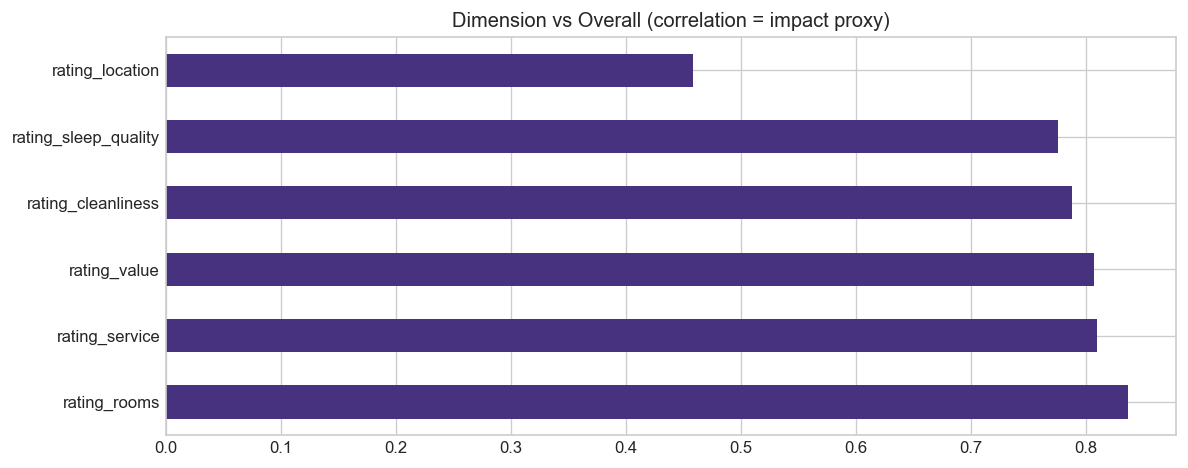

In [11]:

dim_cols = [c for c in RATING_COLUMNS if c != "rating_overall"]
corr_overall = df_valid[dim_cols + ["rating_overall"]].corr()["rating_overall"].drop("rating_overall")
corr_overall = corr_overall.sort_values(ascending=False)
print("Correlation with overall (impact proxy):")
print(corr_overall.round(3).to_string())
corr_overall.plot(kind="barh", figsize=(10, 4), title="Dimension vs Overall (correlation = impact proxy)")
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "satisfaction_drivers_corr.png"), bbox_inches="tight")
plt.show()


### 2.2a Multicollinearity check

Before interpreting OLS coefficients as "drivers", we check whether predictors are highly correlated. **Step 1:** correlation matrix of the dimension ratings (predictors only). **Step 2:** VIF (Variance Inflation Factor). 

Interpretation: VIF &lt; 3 → no concern; 3–5 → moderate; &gt; 10 → severe multicollinearity. If VIF is acceptable, OLS coefficients are stable and interpretable; otherwise we use Ridge regression as a robustness check.

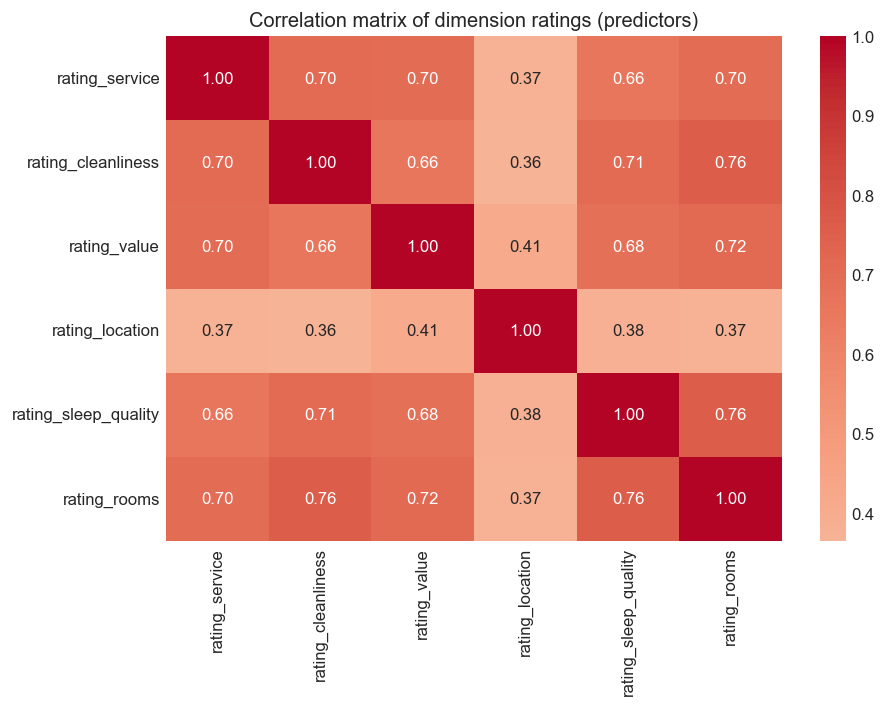

VIF (Variance Inflation Factor):
             feature       VIF
               const 34.222773
      rating_service  2.614120
  rating_cleanliness  2.891504
        rating_value  2.619054
     rating_location  1.240568
rating_sleep_quality  2.814644
        rating_rooms  3.456903

→ Moderate multicollinearity (VIF 3–10). Ridge regression is used below as a robustness check.


In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Use same complete-case subset as for OLS (for consistency)
reg_df = df_valid[dim_cols + ["rating_overall"]].dropna()
X_pred = reg_df[dim_cols]

# 1) Correlation matrix of predictors
corr_matrix = X_pred.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation matrix of dimension ratings (predictors)")
plt.tight_layout()
plt.show()

# 2) VIF (design matrix with constant; no scaling for VIF)
X_for_vif = sm.add_constant(X_pred)
vif_data = pd.DataFrame()
vif_data["feature"] = X_for_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_for_vif.values, i)
    for i in range(X_for_vif.shape[1])
]
print("VIF (Variance Inflation Factor):")
print(vif_data.to_string(index=False))
max_vif = vif_data.loc[vif_data["feature"] != "const", "VIF"].max()
if max_vif < 3:
    print("\n→ All predictor VIFs < 3: limited multicollinearity; OLS coefficients are stable and interpretable.")
elif max_vif < 10:
    print("\n→ Moderate multicollinearity (VIF 3–10). Ridge regression is used below as a robustness check.")
else:
    print("\n→ High multicollinearity (VIF > 10). Ridge regression is used below as a robustness check.")

### 2.2b Multiple Linear Regression

We fit an OLS regression of `rating_overall` on the six dimension ratings (standardized). Coefficients show each dimension’s marginal effect on overall rating when others are held constant; we plot standardized coefficients for comparison. Based on the 2.2a VIF results (max ≈ 3.5, all below 4), multicollinearity is moderate but acceptable, so OLS coefficients are interpretable. We also fit Ridge regression as a robustness check and compare driver rankings.


Sample size (complete cases): 55,928
OLS regression (statsmodels):
                            OLS Regression Results                            
Dep. Variable:         rating_overall   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                 4.661e+04
Date:                Sun, 22 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:27:06   Log-Likelihood:                -38282.
No. Observations:               55928   AIC:                         7.658e+04
Df Residuals:                   55921   BIC:                         7.664e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

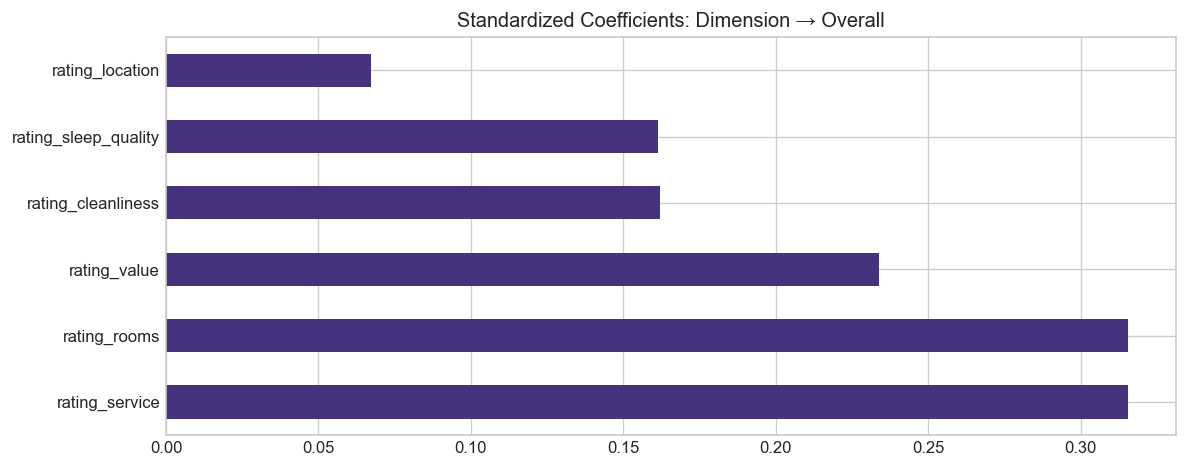

Ridge coefficients (standardized):
rating_service          0.3155
rating_rooms            0.3153
rating_value            0.2338
rating_cleanliness      0.1622
rating_sleep_quality    0.1614
rating_location         0.0671

→ Driver ranking is identical under OLS and Ridge. Ranking remains stable after regularization, indicating limited multicollinearity impact.


In [13]:
import statsmodels.api as sm
from sklearn.linear_model import Ridge

reg_df = df_valid[dim_cols + ["rating_overall"]].dropna()
print(f"Sample size (complete cases): {len(reg_df):,}")
X = reg_df[dim_cols]
y = reg_df["rating_overall"]
X_std = StandardScaler().fit_transform(X)
X_const = sm.add_constant(X_std)

model_ols = sm.OLS(y, X_const).fit()
print("OLS regression (statsmodels):")
print(model_ols.summary())

coef = pd.Series(model_ols.params.iloc[1:].values, index=dim_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
coef.plot(kind="barh", ax=ax, title="Standardized Coefficients: Dimension → Overall")
plt.tight_layout()
plt.show()

# Ridge regression as robustness check (handles multicollinearity)
ridge = Ridge(alpha=1.0)
ridge.fit(X_std, y)
coef_ridge = pd.Series(ridge.coef_, index=dim_cols).sort_values(ascending=False)
rank_ols = coef.reindex(dim_cols).rank(ascending=False)
rank_ridge = coef_ridge.reindex(dim_cols).rank(ascending=False)
rank_diff = (rank_ols - rank_ridge).abs().sum()
print("Ridge coefficients (standardized):")
print(coef_ridge.round(4).to_string())
if rank_diff == 0:
    print("\n→ Driver ranking is identical under OLS and Ridge. Ranking remains stable after regularization, indicating limited multicollinearity impact.")
else:
    print(f"\n→ Rank difference (OLS vs Ridge): {rank_diff}. Driver ranking remains largely consistent; key findings are stable.")


### 2.3 Comparison of the two methods


In [15]:

comp = pd.DataFrame({
    "Pearson(2.1)": corr_overall.reindex(dim_cols),
    "OLS_coef(2.2)": coef.reindex(dim_cols),
})
comp["rank_diff"] = comp["Pearson(2.1)"].rank(ascending=False).astype(int) - comp["OLS_coef(2.2)"].rank(ascending=False).astype(int)
print("2.1 Correlation vs 2.2 OLS coefficients:")
print(comp.round(3).to_string())


2.1 Correlation vs 2.2 OLS coefficients:
                      Pearson(2.1)  OLS_coef(2.2)  rank_diff
rating_service               0.810          0.315          1
rating_cleanliness           0.788          0.162          0
rating_value                 0.807          0.234          0
rating_location              0.458          0.067          0
rating_sleep_quality         0.776          0.161          0
rating_rooms                 0.836          0.315         -1


## 3. Improvement Opportunities

We combine current dimension performance (mean scores and gaps to the maximum) with impact on overall rating to identify where to improve first: market-level metrics (3.1), a priority matrix (3.2), and segment-level analysis by overall rating (3.3).


### 3.1 Market-Level Dimension Performance

We compute the mean and standard deviation of each rating dimension across all reviews, and define *improvement potential* as the gap to the maximum score (5 − mean). 


Dimension performance (market-level):
                       mean    std  improvement_potential
rating_rooms          3.526  1.249                  1.474
rating_value          3.700  1.264                  1.300
rating_service        3.755  1.281                  1.245
rating_sleep_quality  3.834  1.227                  1.166
rating_cleanliness    3.914  1.203                  1.086
rating_location       4.445  0.843                  0.555


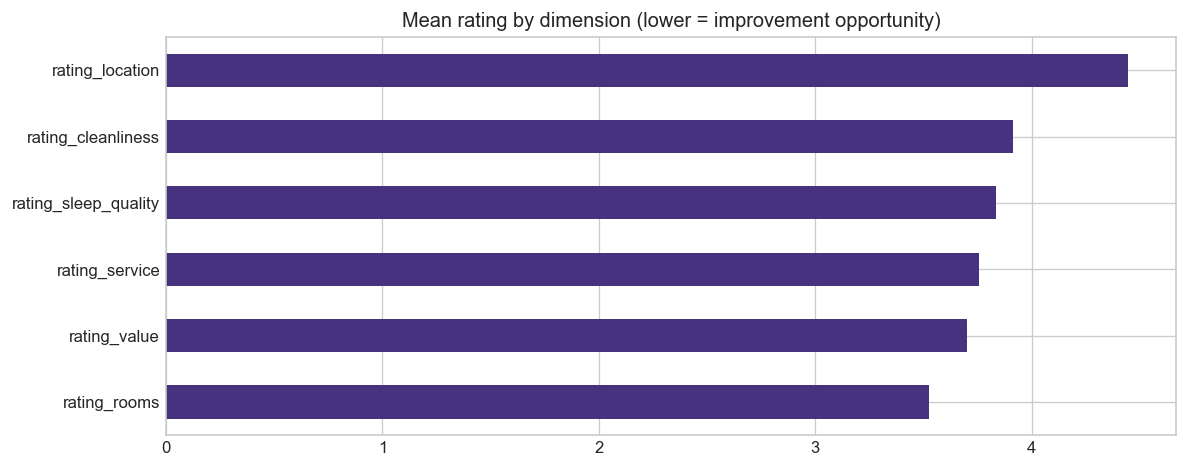

In [29]:
dim_stats = df_valid[dim_cols].agg(["mean", "std"]).T
dim_stats["improvement_potential"] = 5 - dim_stats["mean"]
dim_stats = dim_stats.sort_values("mean")
print("Dimension performance (market-level):")
print(dim_stats.round(3).to_string())
dim_stats["mean"].plot(kind="barh", figsize=(10, 4), title="Mean rating by dimension (lower = improvement opportunity)")
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "improvement_dimension_means.png"), bbox_inches="tight")
plt.show()


### 3.2 Improvement Potential Matrix

We combine each dimension’s **mean score** (x-axis) with its **impact on overall rating** (y-axis, from OLS standardized coefficient, 2.2). The plot is split by medians into quadrants; dimensions in the “low score, high impact” quadrant are the highest priority for improvement.


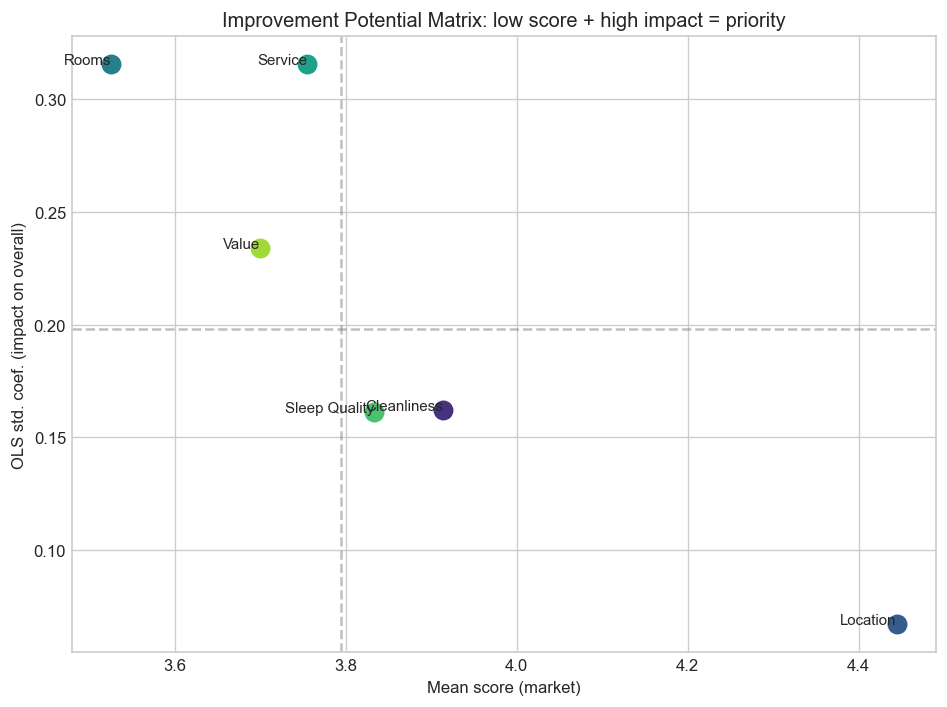

In [36]:

impact = coef.reindex(dim_cols)
score = dim_stats["mean"]
matrix_df = pd.DataFrame({"mean_score": score, "impact": impact})
fig, ax = plt.subplots(figsize=(8, 6))
for i, dim in enumerate(matrix_df.index):
    label = RATING_LABELS.get(dim, dim.replace("rating_", ""))
    ax.scatter(matrix_df.loc[dim, "mean_score"], matrix_df.loc[dim, "impact"], s=120)
    ax.annotate(label, (matrix_df.loc[dim, "mean_score"], matrix_df.loc[dim, "impact"]), fontsize=9, ha="right")
ax.axvline(score.median(), color="gray", linestyle="--", alpha=0.5)
ax.axhline(impact.median(), color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Mean score (market)")
ax.set_ylabel("OLS std. coef. (impact on overall)")
ax.set_title("Improvement Potential Matrix: low score + high impact = priority")
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "improvement_potential_matrix.png"), bbox_inches="tight")
plt.show()


### 3.3 Segment Analysis (by Average Dimension Score)

We segment reviews by average of the 6 dimension scores  into three tiers of equal size (quantile-based: bottom 33%, middle 33%, top 33%). Because we do not segment by overall rating, each segment contains a range of overall scores, so per-segment OLS (overall ~ dimensions) and estimate which dimension’s improvement has the largest effect on overall . Goal: for each tier (low/mid/high dimension-satisfaction), find which dimension to improve first for maximum gain in overall rating. We show (1) dimension means and improvement potential by segment; (2) per-segment OLS (standardized coefficients); the dimension with the largest coefficient is the best lever for that segment.

**Validation:** Before segmenting by average dimension score, we check that this average is positively and linearly related to overall rating; otherwise Low/Mid/High segments would not align with satisfaction level. We report Pearson correlation (and p-value) and a scatter of overall vs. mean dimension score with a fitted line.

Pearson(dim_mean, rating_overall): r = 0.9083, p = 0.00e+00
→ Linear positive relationship: segmenting by dim_mean aligns with overall satisfaction.


/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


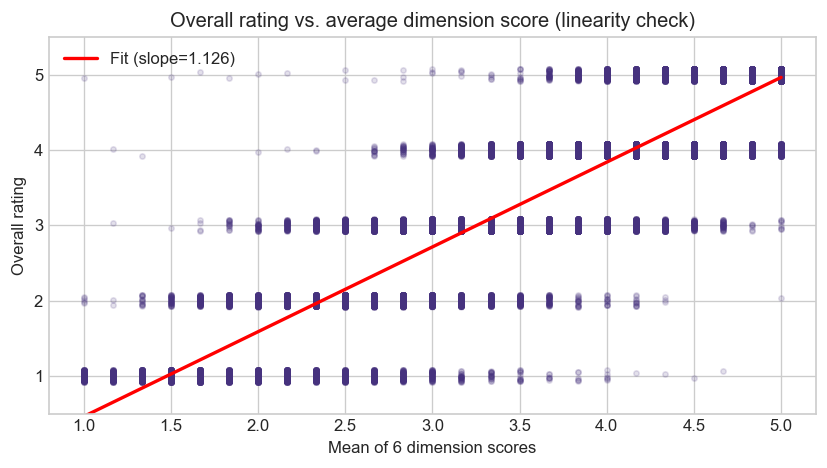

In [33]:
# Same sample as for segmentation (complete cases on all dimensions)
_seg = df_valid.dropna(subset=dim_cols).copy()
_seg["dim_mean"] = _seg[dim_cols].mean(axis=1)
r, p = stats.pearsonr(_seg["dim_mean"], _seg["rating_overall"])
print(f"Pearson(dim_mean, rating_overall): r = {r:.4f}, p = {p:.2e}")
print("→ Linear positive relationship: segmenting by dim_mean aligns with overall satisfaction.")

# Scatter: overall vs dim_mean (add small jitter for discrete overall)
fig, ax = plt.subplots(figsize=(7, 4))
jitter = 0.08
y_jitter = _seg["rating_overall"] + np.random.uniform(-jitter, jitter, size=len(_seg))
ax.scatter(_seg["dim_mean"], y_jitter, alpha=0.15, s=10)
# Fitted line (overall ~ dim_mean)
from sklearn.linear_model import LinearRegression
lm = LinearRegression().fit(_seg[["dim_mean"]], _seg["rating_overall"])
x_line = np.linspace(_seg["dim_mean"].min(), _seg["dim_mean"].max(), 100)
ax.plot(x_line, lm.predict(x_line.reshape(-1, 1)), "r-", lw=2, label=f"Fit (slope={lm.coef_[0]:.3f})")
ax.set_xlabel("Mean of 6 dimension scores")
ax.set_ylabel("Overall rating")
ax.set_title("Overall rating vs. average dimension score (linearity check)")
ax.legend()
ax.set_ylim(0.5, 5.5)
plt.tight_layout()
plt.show()

Segment boundaries (mean of 6 dimensions): 33% ≤ 3.67 | 67% ≤ 4.5
Segment sizes:
segment
Low (bottom 33%)    19850
Mid (middle 33%)    19826
High (top 33%)      16252

Dimension means by segment:
                  rating_service  rating_cleanliness  rating_value  rating_location  rating_sleep_quality  rating_rooms
segment                                                                                                                
Low (bottom 33%)           2.614               2.842         2.567            4.017                 2.638         2.374
Mid (middle 33%)           4.155               4.287         4.078            4.602                 4.158         3.837
High (top 33%)             4.901               4.941         4.770            4.896                 4.894         4.783



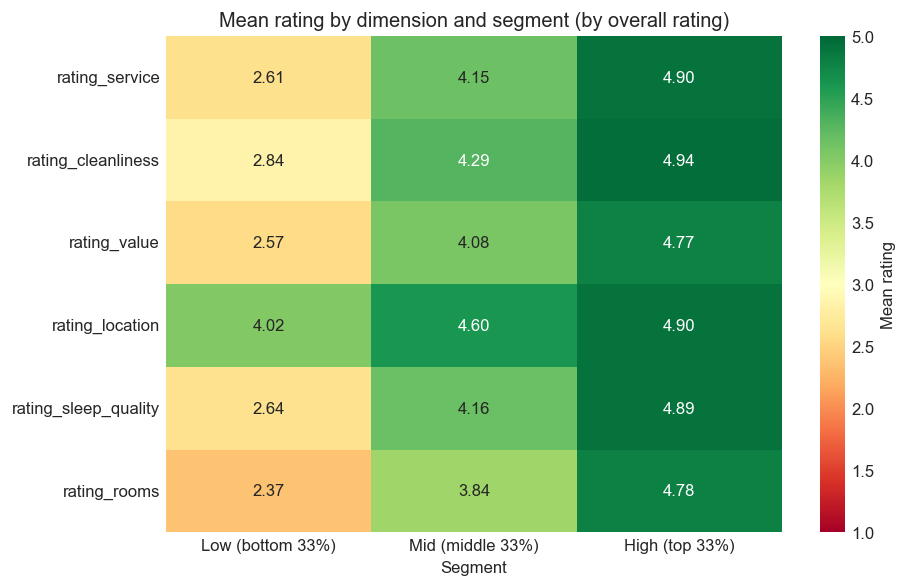

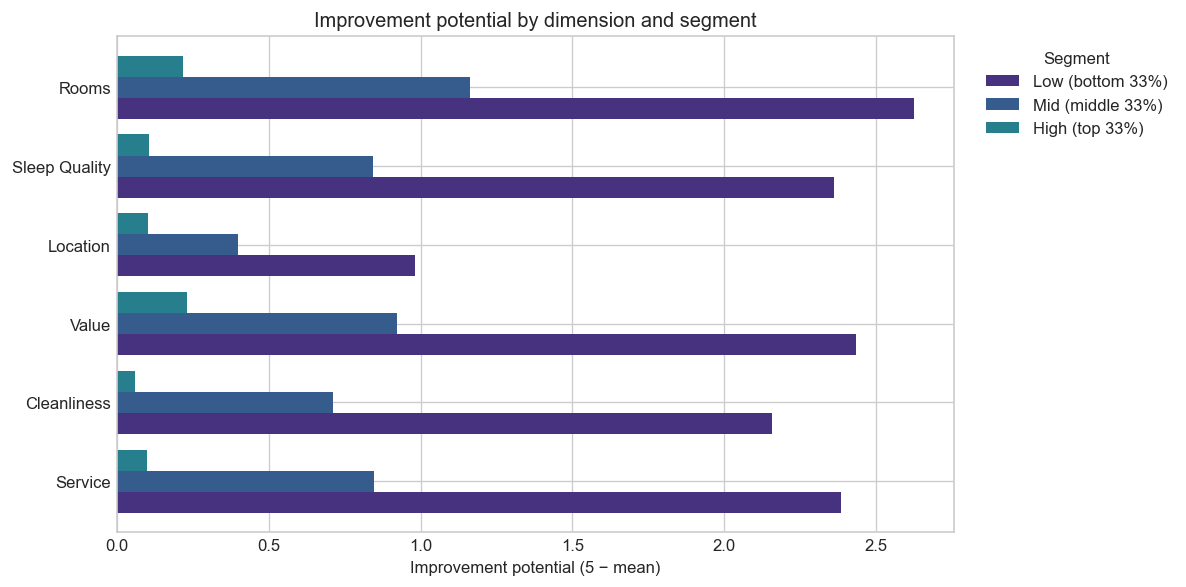

In [34]:
# Define segments by *average of the 6 dimensions* (continuous), not by overall.
# So within each segment, overall rating still varies → per-segment OLS is valid.
seg_df = df_valid.dropna(subset=dim_cols).copy()
seg_df["dim_mean"] = seg_df[dim_cols].mean(axis=1)
q33 = seg_df["dim_mean"].quantile(1/3)
q67 = seg_df["dim_mean"].quantile(2/3)

def segment_by_dim_mean(r):
    if r <= q33:
        return "Low (bottom 33%)"
    if r <= q67:
        return "Mid (middle 33%)"
    return "High (top 33%)"

seg_df["segment"] = seg_df["dim_mean"].map(segment_by_dim_mean)
segment_order = ["Low (bottom 33%)", "Mid (middle 33%)", "High (top 33%)"]
seg_df["segment"] = pd.Categorical(seg_df["segment"], categories=segment_order, ordered=True)

print("Segment boundaries (mean of 6 dimensions): 33% ≤", round(q33, 2), "| 67% ≤", round(q67, 2))
print("Segment sizes:")
print(seg_df["segment"].value_counts().sort_index().to_string())
print()

# Dimension means by segment
seg_means = seg_df.groupby("segment", observed=True)[dim_cols].mean()
seg_means_T = seg_means[dim_cols].T  # dimensions × segments

print("Dimension means by segment:")
print(seg_means[dim_cols].round(3).to_string())
print()

# Heatmap: dimension (rows) × segment (columns)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    seg_means_T,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=3,
    vmin=1,
    vmax=5,
    ax=ax,
    cbar_kws={"label": "Mean rating"},
)
ax.set_title("Mean rating by dimension and segment (by overall rating)")
ax.set_xlabel("Segment")
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "improvement_segment_heatmap.png"), bbox_inches="tight")
plt.show()

# Improvement potential by segment: (5 - mean) per dimension (rows = dimensions, cols = segments)
improve_by_seg = (5 - seg_means[dim_cols]).T
improve_by_seg.index = [RATING_LABELS.get(c, c.replace("rating_", "")) for c in dim_cols]
improve_by_seg.plot(kind="barh", figsize=(10, 5), width=0.8, xlabel="Improvement potential (5 − mean)")
plt.title("Improvement potential by dimension and segment")
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "improvement_segment_bars.png"), bbox_inches="tight")
plt.show()

To give better improvement recommendations for hotels at different score levels, we identify for each segment the dimension that this segment should improve first—i.e., the dimension for which improvement has the largest effect on overall rating compared with improving other dimensions. We run OLS within each segment; the standardized coefficient of a dimension is the marginal effect on overall rating. The dimension with the largest coefficient in a segment is thus the lever that moves overall the most per unit improvement. We also compute a priority score (coefficient × improvement potential) to combine impact with room to improve.

Standardized coefficient (marginal effect on overall) by segment:
               Low (bottom 33%)  Mid (middle 33%)  High (top 33%)
Service                  0.2718            0.1608          0.0935
Cleanliness              0.1553            0.0677          0.0393
Value                    0.2619            0.0910          0.0409
Location                 0.0660            0.0512          0.0331
Sleep Quality            0.1537            0.0637          0.0344
Rooms                    0.2250            0.1553          0.1228

Recommended focus per segment (dimension whose improvement moves overall the most):
  Low (bottom 33%): Service (coef = 0.2718)
  Mid (middle 33%): Service (coef = 0.1608)
  High (top 33%): Rooms (coef = 0.1228)

Priority score (coef × improvement potential) by segment:
               Low (bottom 33%)  Mid (middle 33%)  High (top 33%)
Service                  0.6484            0.1359          0.0092
Cleanliness              0.3351            0.0482          0.0023
Va

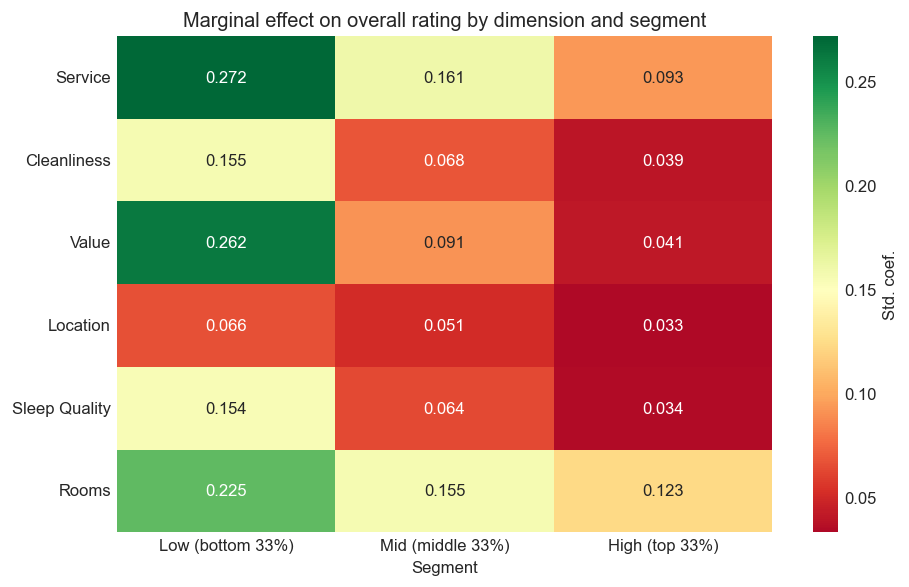

In [35]:
# Per-segment OLS: overall ~ dimensions (standardized within segment)
import statsmodels.api as sm
coef_by_seg = pd.DataFrame(index=dim_cols, columns=segment_order)
priority_by_seg = pd.DataFrame(index=dim_cols, columns=segment_order)  # coef * (5 - mean)

for seg in segment_order:
    sub = seg_df[seg_df["segment"] == seg]
    if len(sub) < 50:
        continue
    X = sub[dim_cols]
    y = sub["rating_overall"]
    # Skip if y has no variance (OLS not identified)
    if y.std() < 1e-10:
        print(f"Segment '{seg}' has no variance in overall rating (all same value). Skipping OLS for this segment.")
        continue
    X_std = StandardScaler().fit_transform(X)
    X_const = sm.add_constant(X_std)
    model = sm.OLS(y, X_const).fit()
    # Coefficients are in same order as dim_cols (X = sub[dim_cols]); params index is x1,x2,... so use .values
    coef_by_seg[seg] = model.params.iloc[1:].values
    # Priority = marginal effect × room to improve (5 - mean in this segment)
    means_seg = seg_means.loc[seg, dim_cols]
    priority_by_seg[seg] = coef_by_seg[seg].astype(float) * (5 - means_seg).values

coef_by_seg = coef_by_seg.astype(float)
priority_by_seg = priority_by_seg.astype(float)

# Label rows for display
coef_display = coef_by_seg.copy()
coef_display.index = [RATING_LABELS.get(c, c.replace("rating_", "")) for c in dim_cols]
print("Standardized coefficient (marginal effect on overall) by segment:")
print(coef_display.round(4).to_string())
print()

# For each segment: dimension with largest coefficient = "improve this for max gain in overall"
print("Recommended focus per segment (dimension whose improvement moves overall the most):")
for seg in segment_order:
    if coef_by_seg[seg].notna().all() and coef_by_seg[seg].notna().any():
        best_dim = coef_by_seg[seg].idxmax()
        best_label = RATING_LABELS.get(best_dim, best_dim.replace("rating_", ""))
        print(f"  {seg}: {best_label} (coef = {coef_by_seg.loc[best_dim, seg]:.4f})")
    else:
        print(f"  {seg}: N/A (no variance in overall rating in this segment)")
print()

# Priority = coef × improvement potential (impact × room to improve)
priority_display = priority_by_seg.copy()
priority_display.index = [RATING_LABELS.get(c, c.replace("rating_", "")) for c in dim_cols]
print("Priority score (coef × improvement potential) by segment:")
print(priority_display.round(4).to_string())
print()
print("Recommended focus by priority (coef × gap) per segment:")
for seg in segment_order:
    if priority_by_seg[seg].notna().all() and priority_by_seg[seg].notna().any():
        best_dim = priority_by_seg[seg].idxmax()
        best_label = RATING_LABELS.get(best_dim, best_dim.replace("rating_", ""))
        print(f"  {seg}: {best_label}")
    else:
        print(f"  {seg}: N/A (no variance in overall rating in this segment)")

# Heatmap: standardized coefficient by dimension and segment
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(coef_display.astype(float), annot=True, fmt=".3f", cmap="RdYlGn", center=0.15, ax=ax, cbar_kws={"label": "Std. coef."})
ax.set_title("Marginal effect on overall rating by dimension and segment")
ax.set_xlabel("Segment")
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "improvement_segment_coef_heatmap.png"), bbox_inches="tight")
plt.show()

### 3.4. Negative Review Theme Extraction

We subset reviews with low overall rating (e.g. ≤ 2), concatenate their text, and extract frequent terms or themes (e.g. via frequency counts or simple keyword lists) to summarize what dissatisfied guests mention most.


Top words in negative reviews (overall<=2):
  night: 8217
  staff: 6731
  about: 6554
  desk: 6404
  like: 5969
  time: 5854
  after: 5623
  front: 5384
  location: 5340
  bathroom: 5230
  good: 5206
  service: 4915
  small: 4889
  told: 4862
  place: 4715


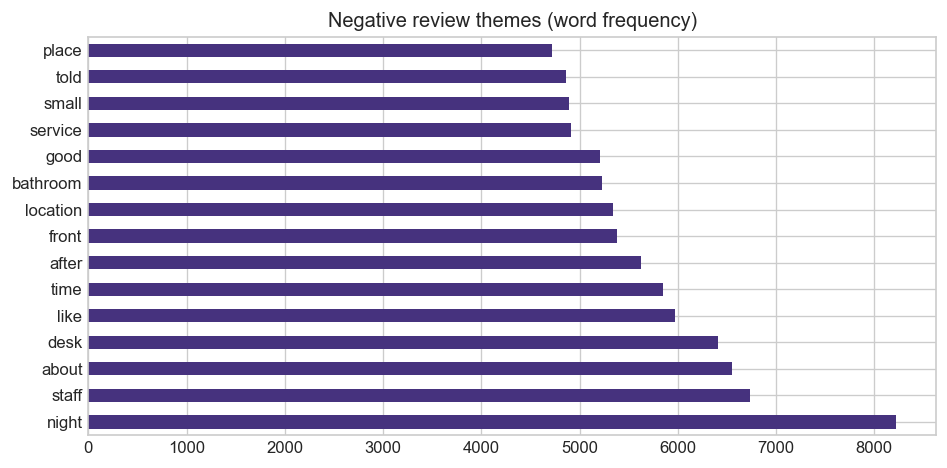

In [30]:
neg = df_valid[df_valid["rating_overall"] <= 2]
neg_text = " ".join(neg["text"].dropna().astype(str).str.lower())
import re
from collections import Counter
words = re.findall(r"\b[a-z]{4,}\b", neg_text)
stop = {"hotel", "room", "rooms", "stay", "stayed", "would", "could", "have", "were", "this", "that", "with", "from", "they", "when", "what", "which", "very", "just", "only", "even", "also", "some", "into", "more", "than", "been", "were", "there", "here"}
words = [w for w in words if w not in stop]
top_words = Counter(words).most_common(15)
print("Top words in negative reviews (overall<=2):")
for w, c in top_words:
    print(f"  {w}: {c}")
pd.Series(dict(top_words)).plot(kind="barh", figsize=(8, 4), title="Negative review themes (word frequency)")
plt.tight_layout()
plt.show()


## 4 Word cloud

We build a word cloud from review text (optionally filtered by rating or segment) to visualize the most frequent words and give a quick qualitative sense of what guests talk about.


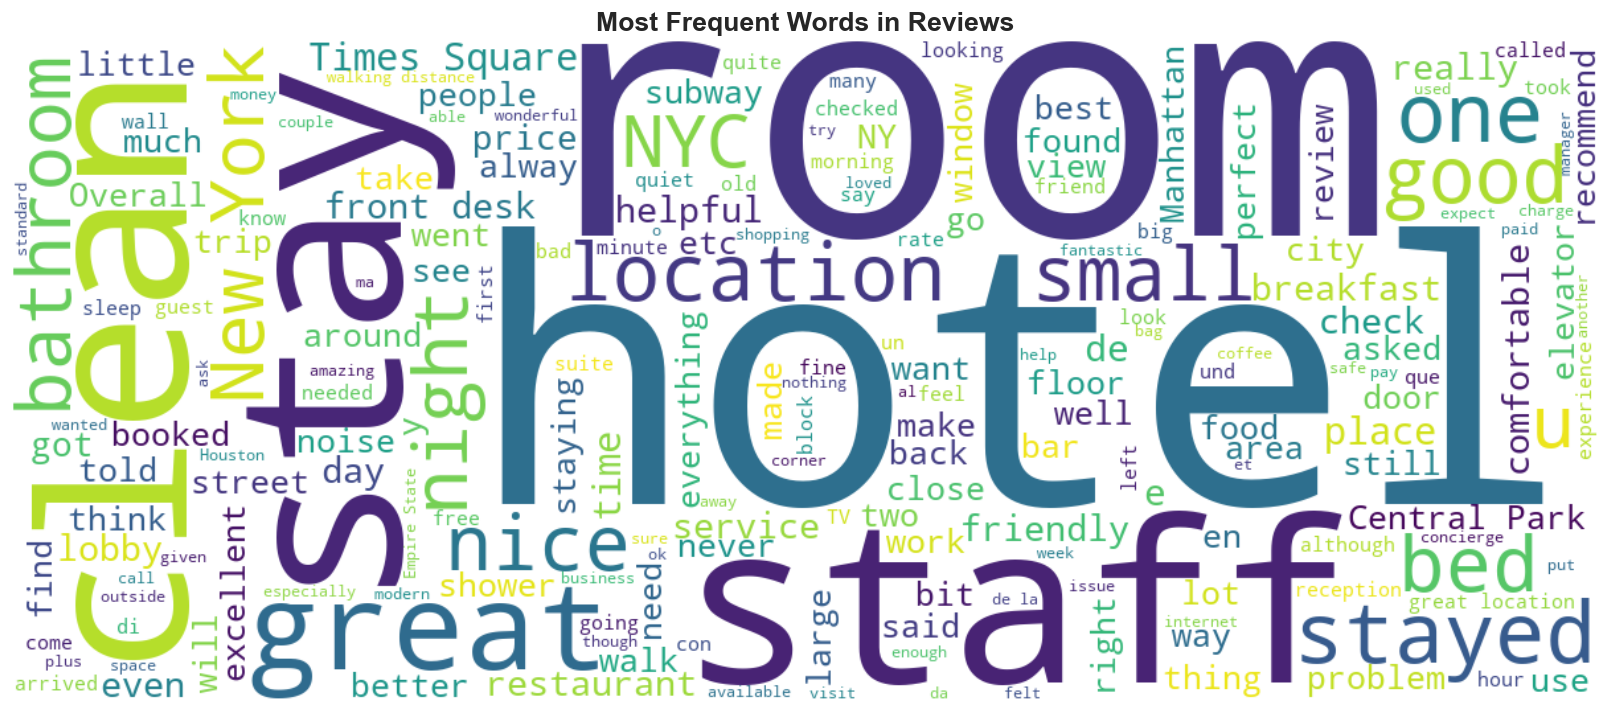

In [37]:
try:
    from wordcloud import WordCloud
    text_sample = " ".join(df["text"].dropna().sample(5000, random_state=42))
    wc = WordCloud(width=1200, height=500, background_color="white",
                   colormap="viridis", max_words=200).generate(text_sample)
    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Most Frequent Words in Reviews", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.savefig(str(REPORTS_DIR / "wordcloud.png"), bbox_inches="tight")
    plt.show()
except ImportError:
    print("Install wordcloud: pip install wordcloud")


In [17]:
conn.close()
print("EDA complete ✓")


EDA complete ✓
